# SurgeShield — Exploratory Data Analysis

**OSEMN stage: Explore (E)**

This notebook narrates the exploratory analysis. The headless, reproducible
version lives in `eda.py` in this folder, which regenerates every figure into
`3_eda/figures/`. We **import** `eda.py` here so the notebook and the
production script never drift — the notebook explains; the script is the
source of truth.

EDA has one job in this project: to *visualize* what the signal-validation step
(`2_data_cleaning/validate_dataset.py`) already established numerically — that
the features do not separate flood from no-flood. Each figure below is a
different view of that same finding.

Reads from `../1_data/processed/flood_clean.csv`.

In [1]:
import pandas as pd
from IPython.display import Image, display

# eda.py lives in this folder; import it as a module.
import eda

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

df = eda.load_data()
df.head()

[load] flood_clean.csv: 10,000 rows x 12 cols


,Rainfall,Temperature,Humidity,River Discharge,Water Level,Elevation,Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1
1,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0


In [2]:
# Numeric summary — note how similar the spread is regardless of the target.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rainfall,10000.0,150.015118,86.032127,0.014437,76.124373,150.620428,223.402156,299.970293
Temperature,10000.0,29.961401,8.669838,15.000166,22.405717,30.000907,37.413488,44.993681
Humidity,10000.0,59.749104,23.142734,20.001339,39.541778,59.497375,80.038163,99.997772
River Discharge,10000.0,2515.722946,1441.706442,0.042161,1284.782376,2530.451944,3767.229862,4999.698480
Water Level,10000.0,5.017881,2.876579,0.002701,2.538847,5.042094,7.524692,9.996899
Elevation,10000.0,4417.138177,2530.245421,1.150340,2229.681903,4417.199761,6616.729066,8846.894877
Population Density,10000.0,5021.468442,2882.591520,2.289000,2491.766601,5074.392879,7474.228752,9999.169530
Infrastructure,10000.0,0.502000,0.500021,0.000000,0.000000,1.000000,1.000000,1.000000
Historical Floods,10000.0,0.498700,0.500023,0.000000,0.000000,0.000000,1.000000,1.000000
Flood Occurred,10000.0,0.505700,0.499993,0.000000,0.000000,1.000000,1.000000,1.000000


## 1. Target balance

How many records are floods vs. no-floods? A near-perfect 50/50 split is the
first hint that the features may not separate the classes — if they did, we
would not expect the labels to look so close to a coin flip.

[save] 3_eda\figures\target_balance.png

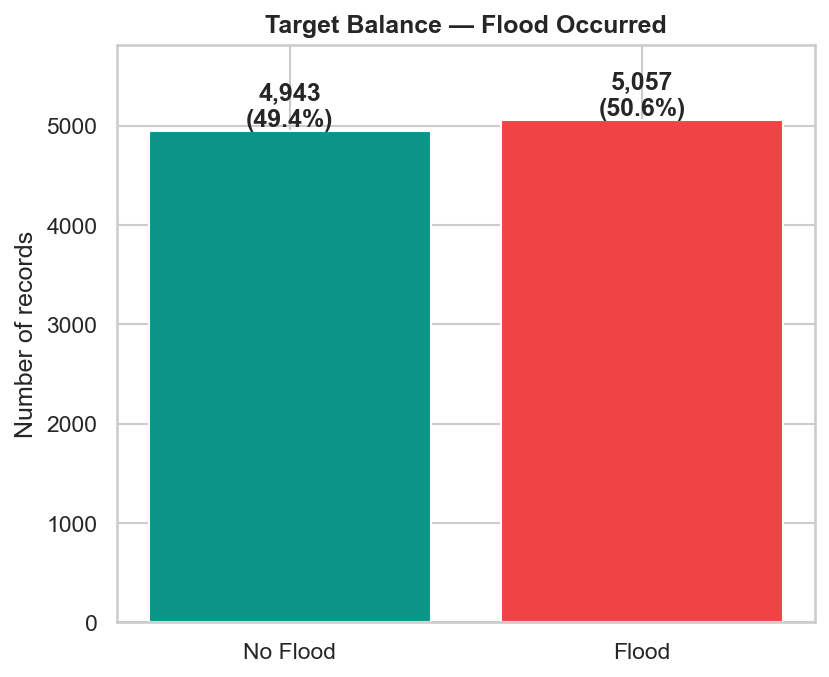

In [3]:
eda.plot_target_balance(df)
display(Image(filename=str(eda.FIG_DIR / 'target_balance.png')))

## 2. Feature distributions by class

For each numeric feature we overlay the distribution for flood vs. no-flood. If
a feature carried signal, the two distributions would be shifted or shaped
differently. Here they sit almost exactly on top of one another — the classes
are indistinguishable on every feature.

[save] 3_eda\figures\feature_distributions.png


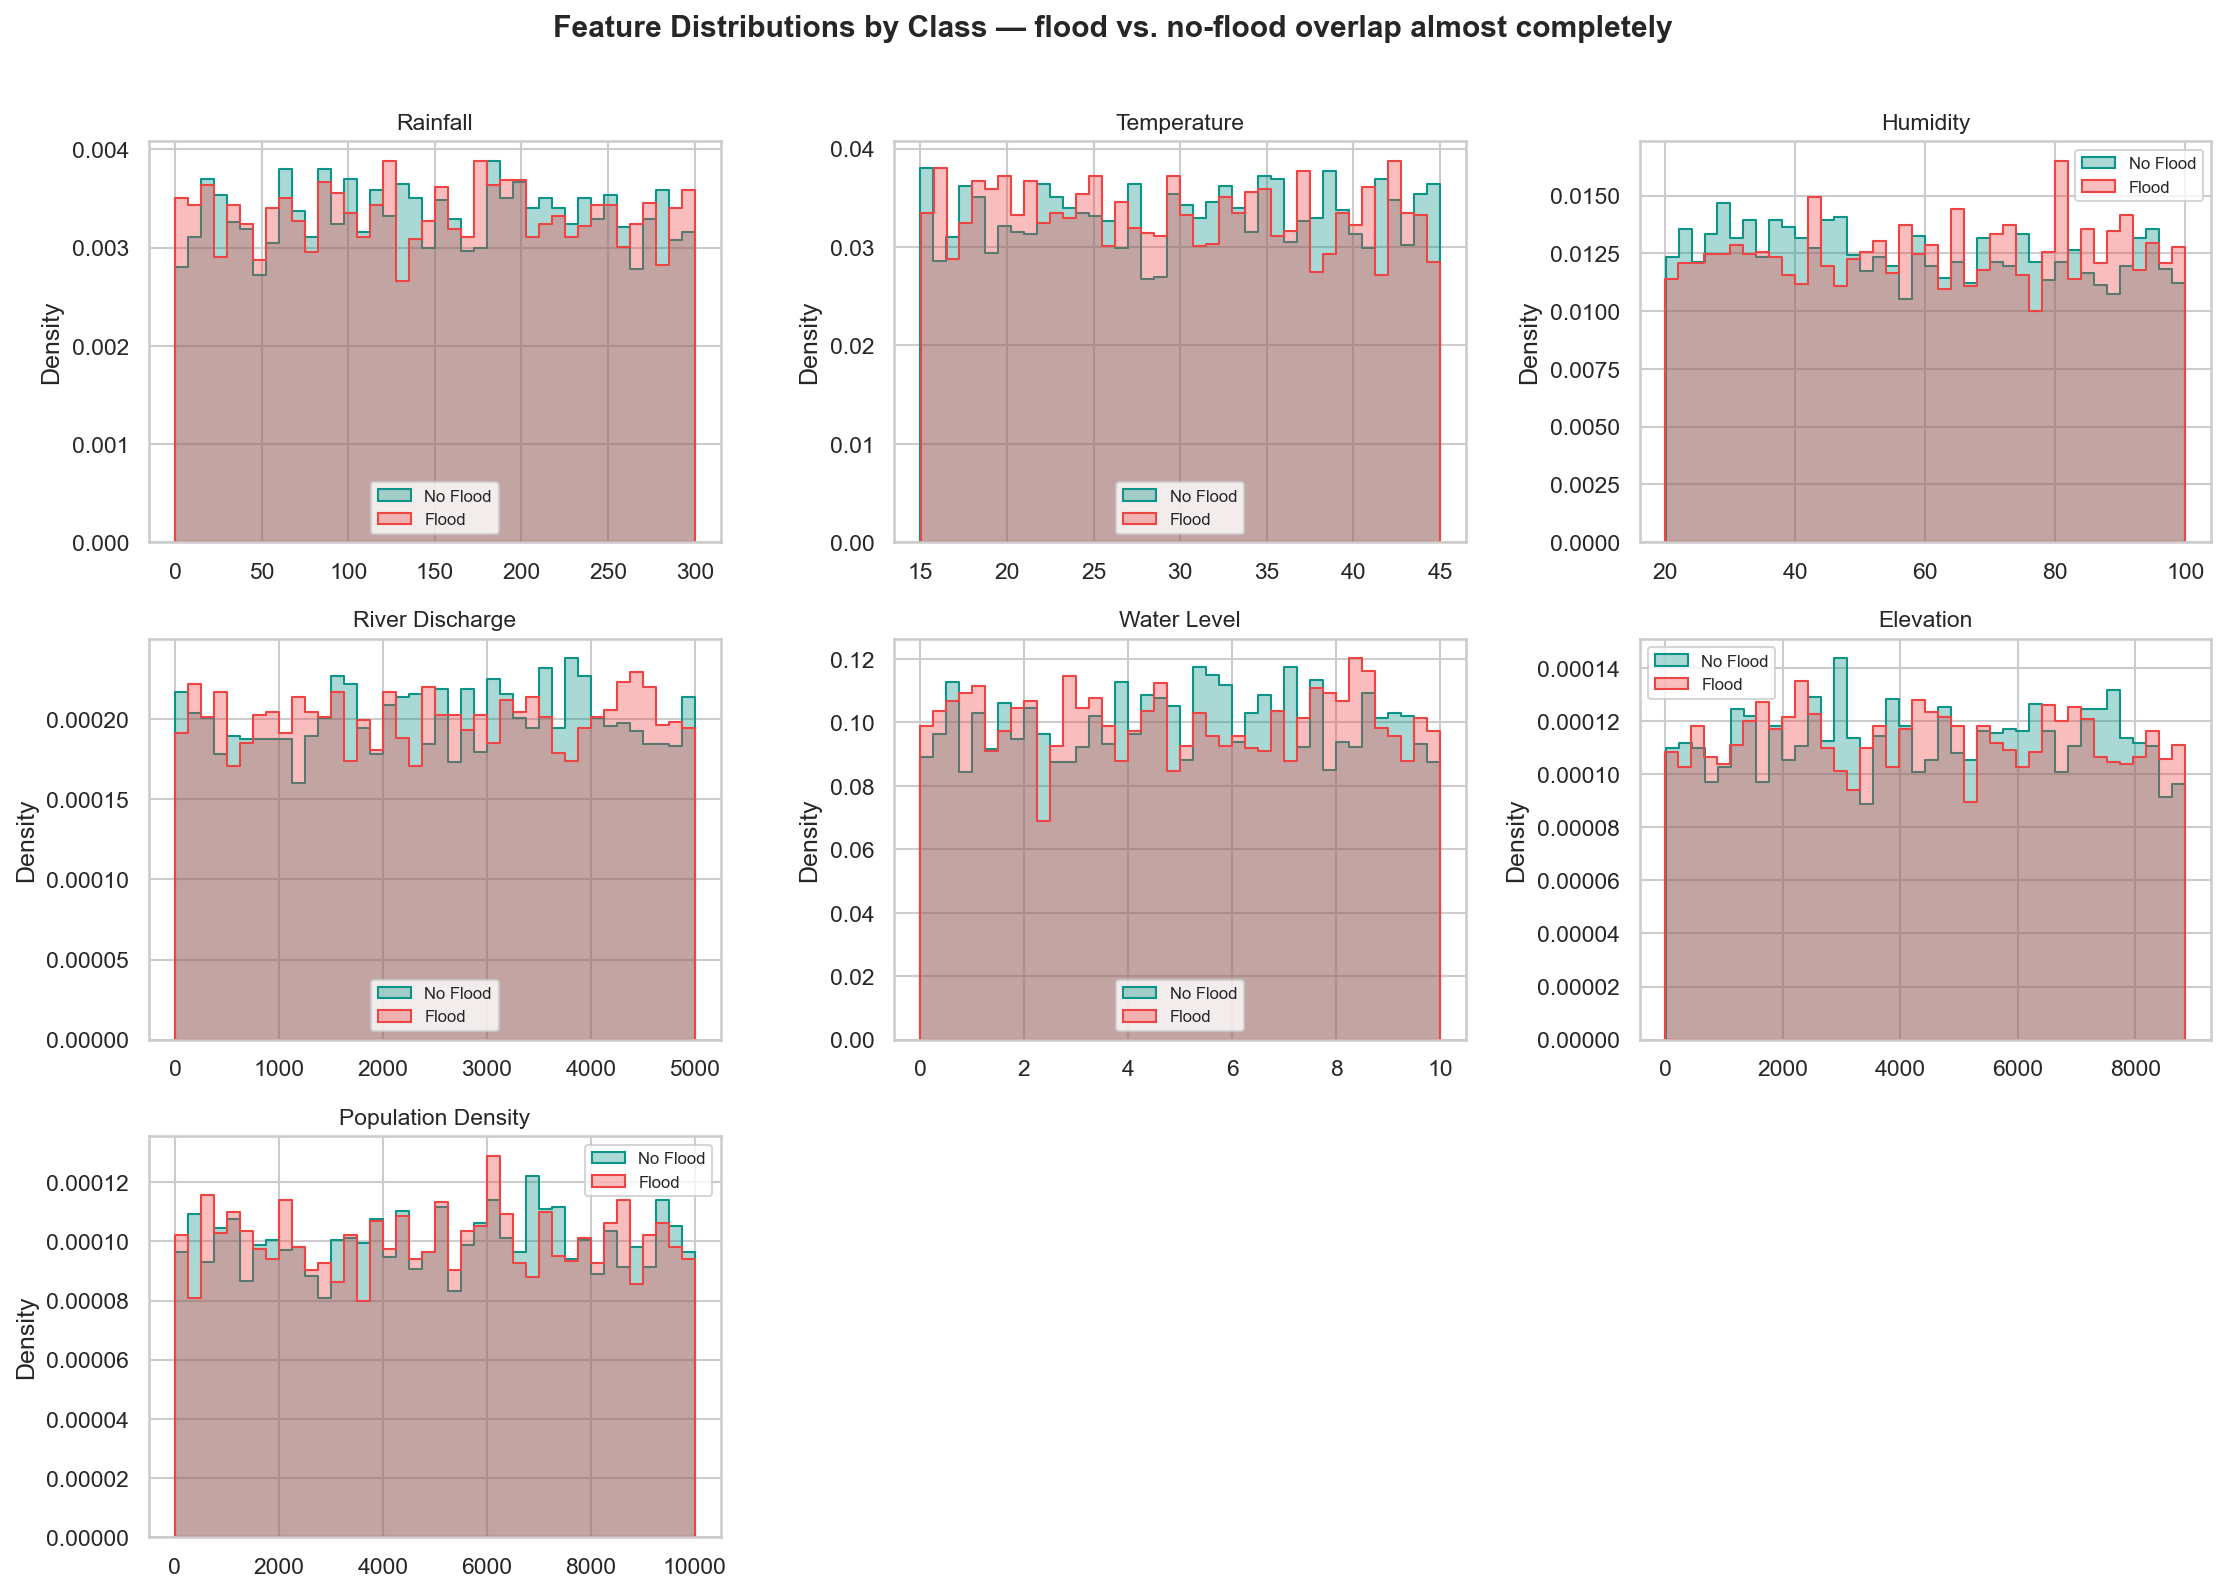

In [4]:
eda.plot_feature_distributions(df)
display(Image(filename=str(eda.FIG_DIR / 'feature_distributions.png')))

## 3. Feature/target correlation heatmap

Categoricals are one-hot expanded so the whole matrix is numeric. The decisive
row/column is `Flood Occurred`: every correlation with the target is near zero
(within ±0.03). This is the visual counterpart of Diagnostic 1 in the
validation report.

[save] 3_eda\figures\correlation_heatmap.png


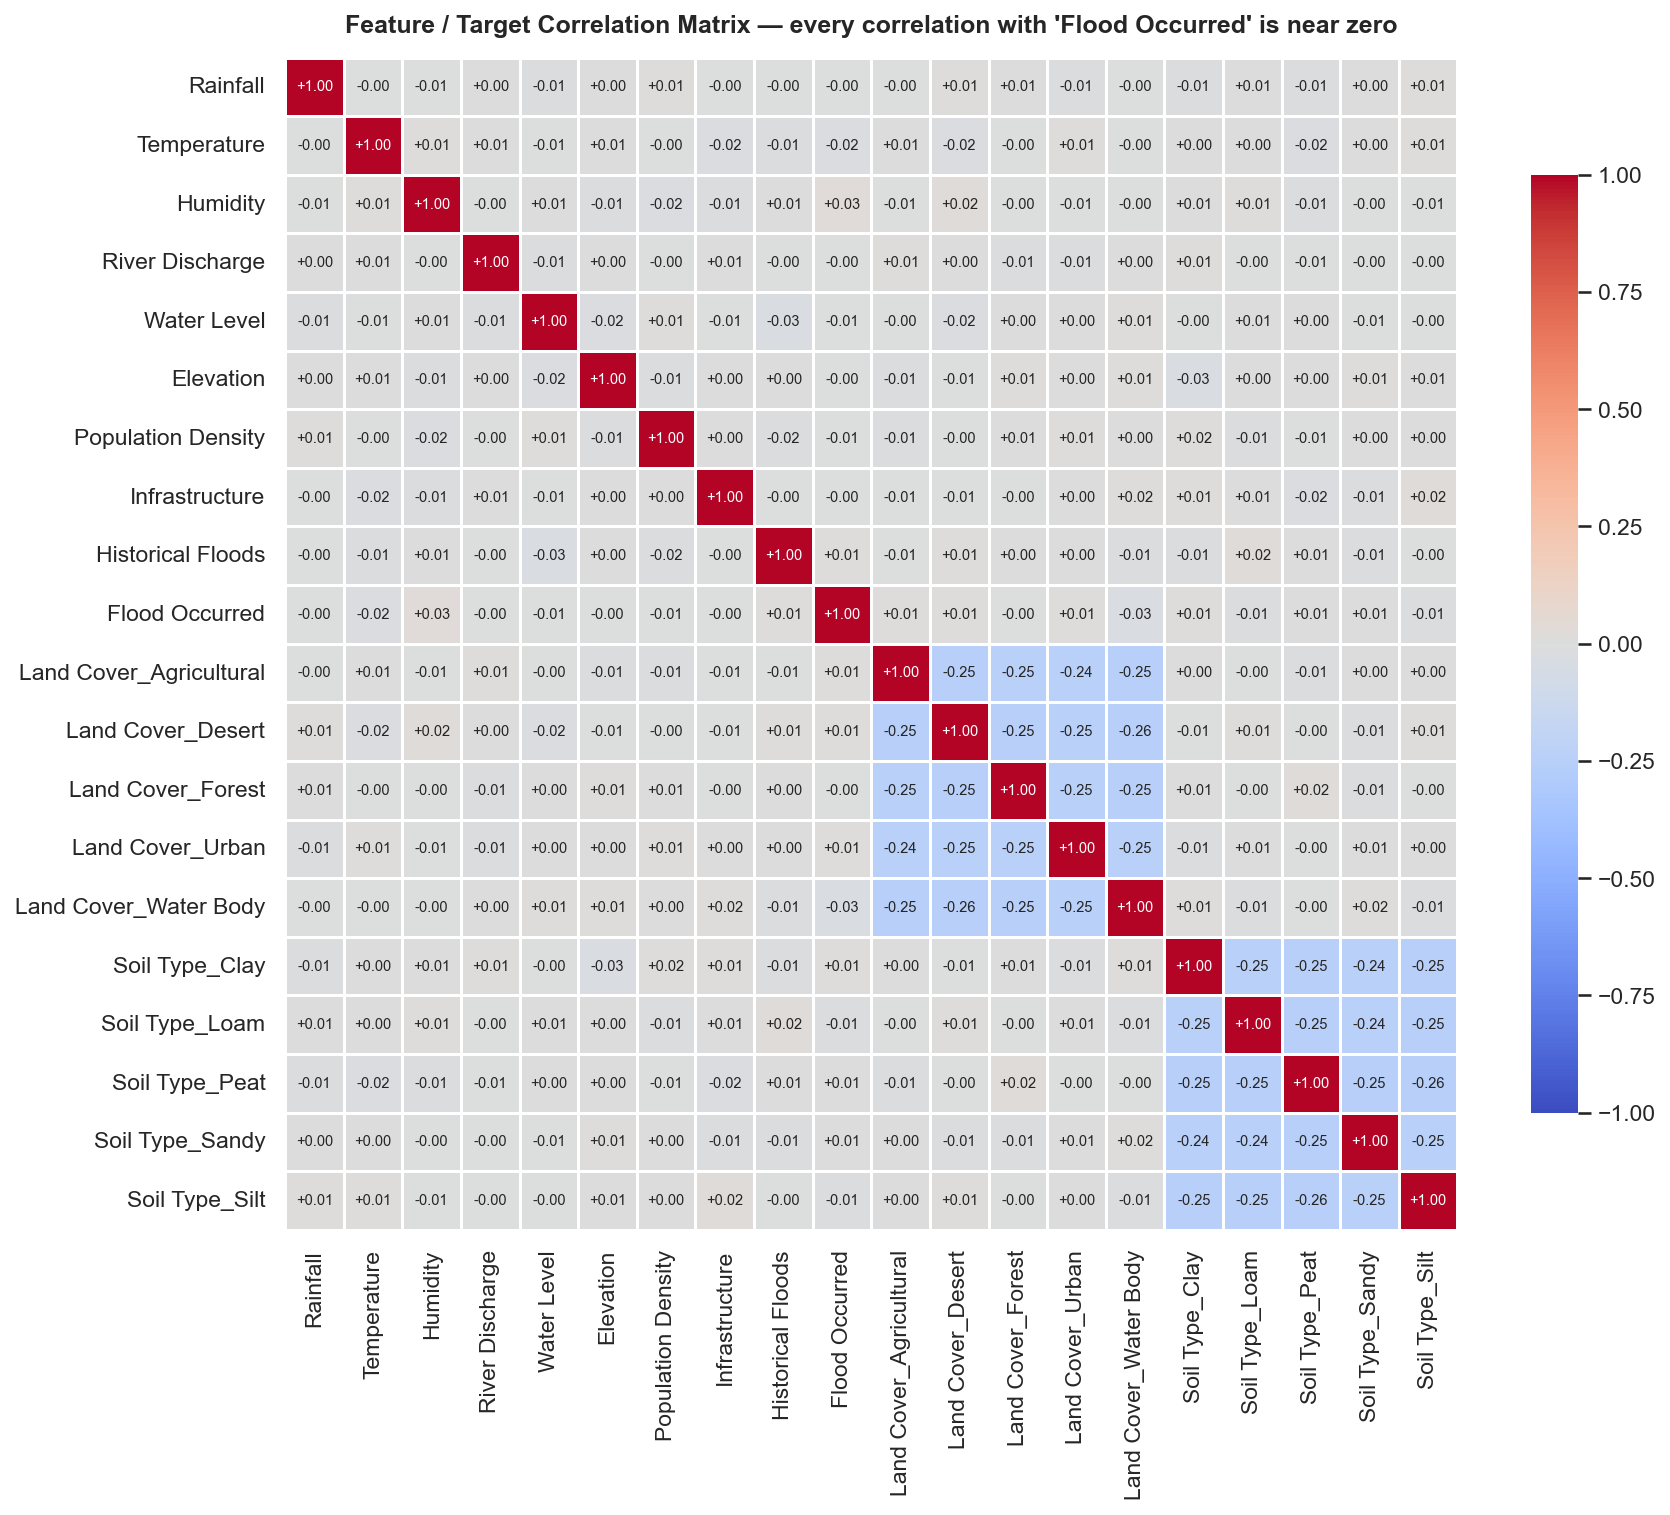

In [5]:
eda.plot_correlation_heatmap(df)
display(Image(filename=str(eda.FIG_DIR / 'correlation_heatmap.png')))

## 4. Flood rate by category

For the two categorical features (`Land Cover`, `Soil Type`) we plot the flood
rate within each category against the overall ~50.6% baseline (red dashed line).
A predictive category would sit well above or below the line. Instead every bar
hugs ~50% — no category shifts the odds of a flood.

[save] 3_eda\figures\flood_rate_by_category.png


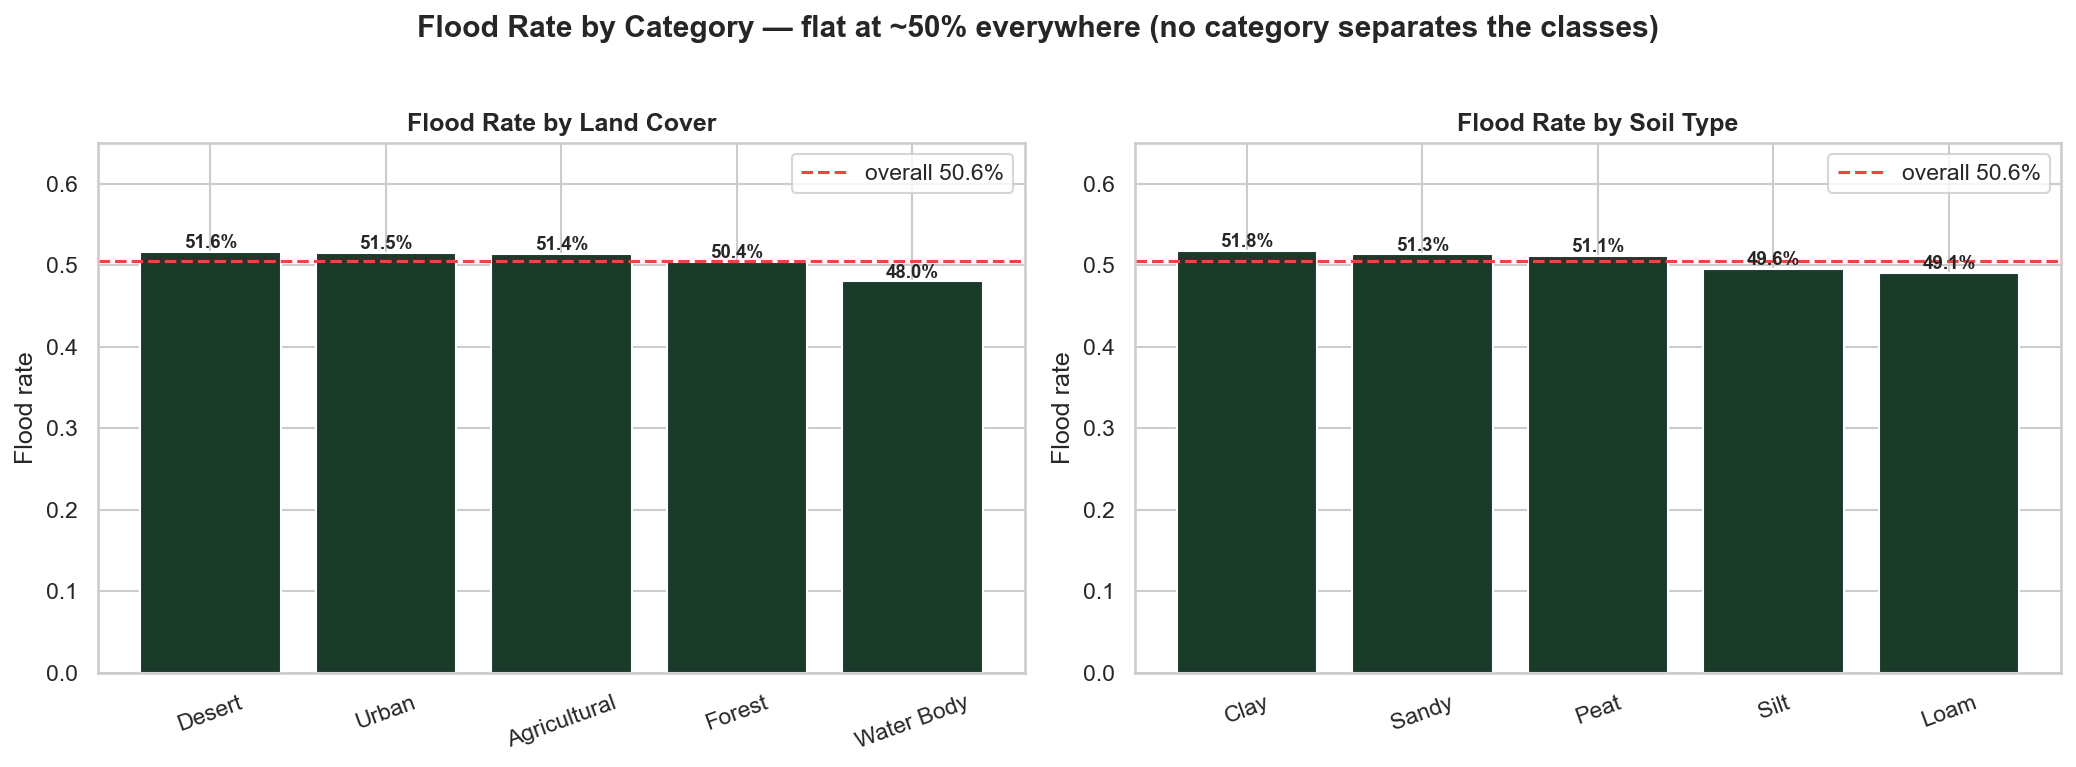

In [6]:
eda.plot_flood_rate_by_category(df)
display(Image(filename=str(eda.FIG_DIR / 'flood_rate_by_category.png')))

## 5. Numeric features by class (boxplots)

Where the histograms in §2 showed distribution *shape*, boxplots summarize *medians and quartiles*. If a feature carried signal, the flood and no-flood boxes would sit at different heights. Here every box pair lines up almost exactly — another angle on the same no-separation result.

[save] 3_eda\figures\feature_boxplots_by_class.png


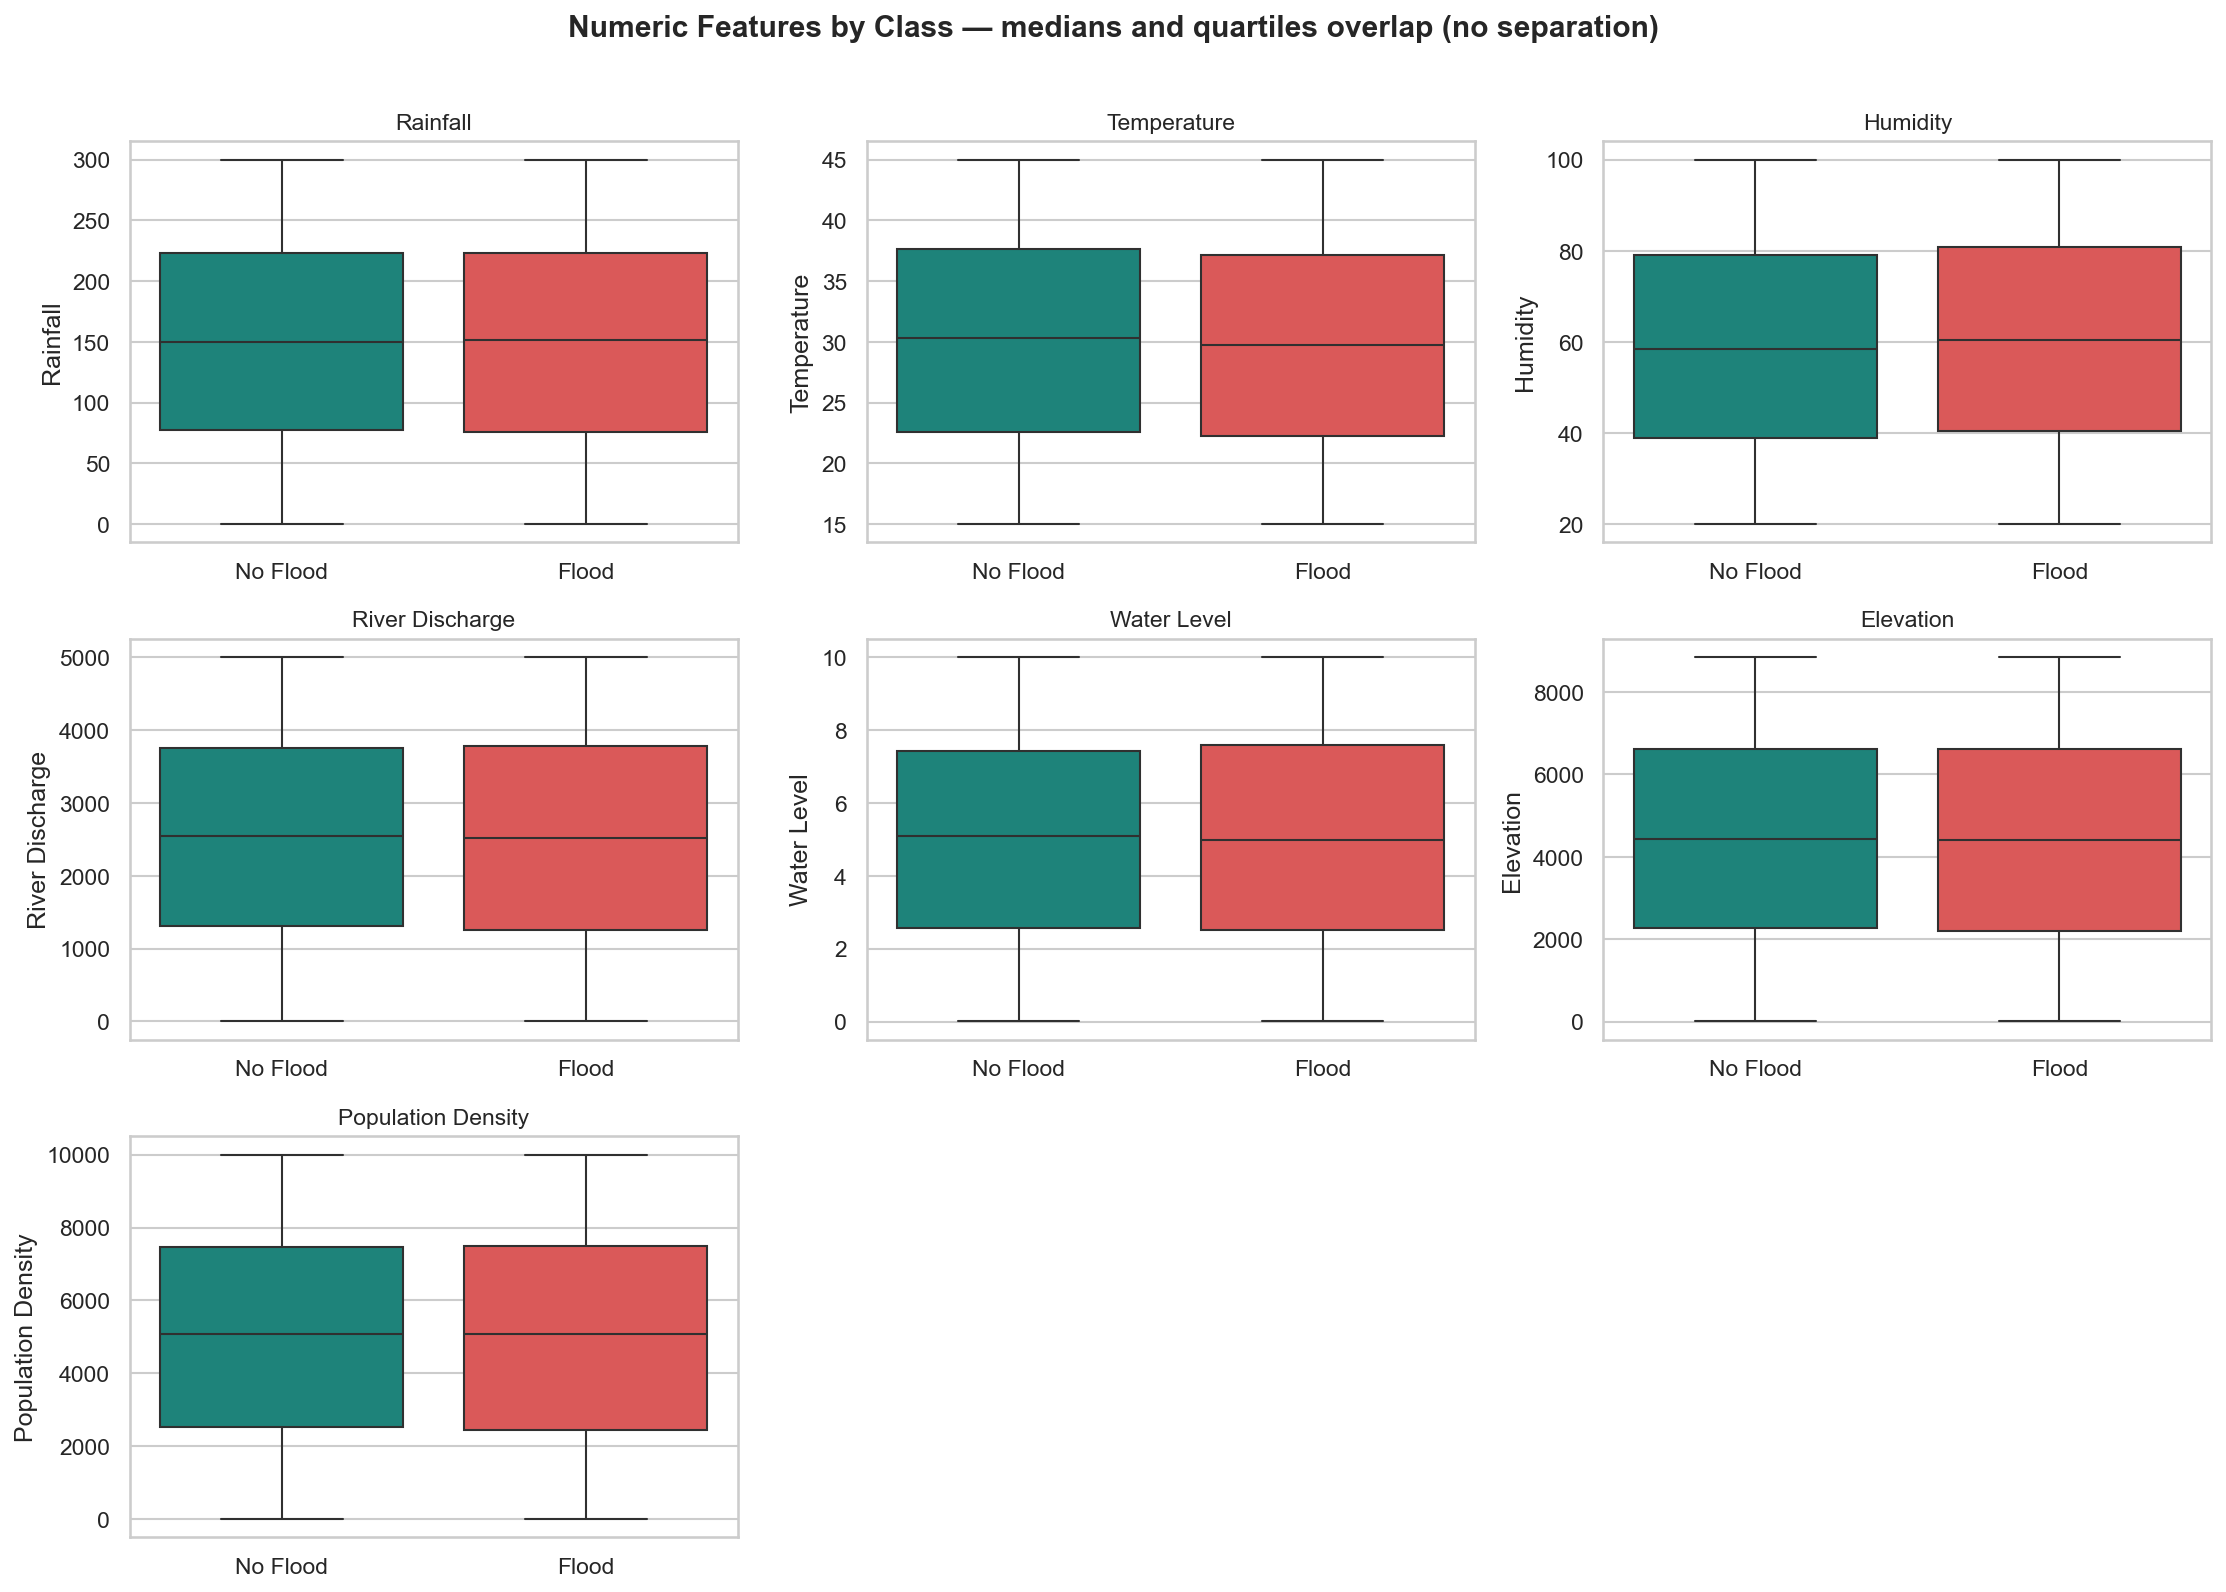

In [7]:
eda.plot_feature_boxplots_by_class(df)
display(Image(filename=str(eda.FIG_DIR / 'feature_boxplots_by_class.png')))

## 6. Categorical composition

A descriptive view of how the dataset is built: how many records fall in each `Land Cover` and `Soil Type` category, independent of the target. This frames the flood-rate-by-category chart in §4 — the categories are well populated, so the flat ~50% rates are not an artifact of tiny groups.

[save] 3_eda\figures\categorical_composition.png


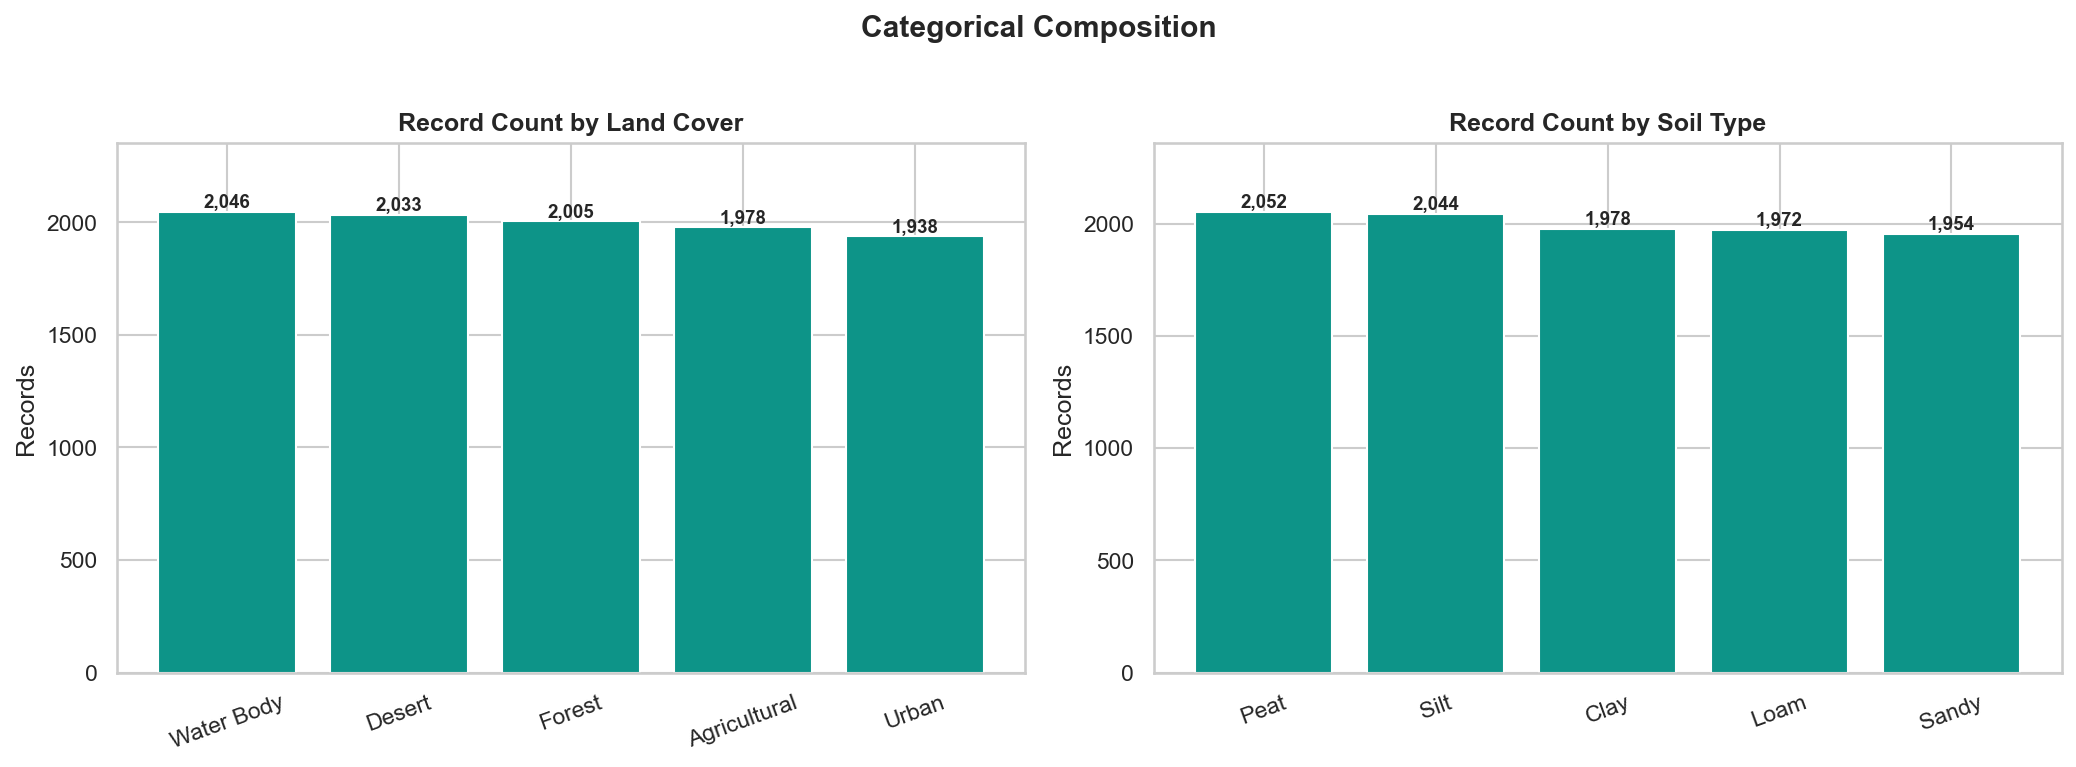

In [8]:
eda.plot_categorical_composition(df)
display(Image(filename=str(eda.FIG_DIR / 'categorical_composition.png')))

## Conclusion

All six views tell the same story:

- **Target balance** is a near-perfect coin flip (~50.6% / 49.4%).
- **Feature distributions** for flood and no-flood overlap almost completely.
- **Correlations** with the target are all near zero.
- **Flood rate by category** is flat at ~50% across every Land Cover and Soil Type.
- **Boxplots by class** show matching medians and quartiles for both classes.
- **Categorical composition** confirms the categories are well populated, so the flat flood rates are not a small-sample artifact.

This visually corroborates the numerical finding from the Scrub stage: **the dataset carries no learnable signal**. The figures saved to `3_eda/figures/` are reused in dissertation Chapter 4 and the analytics UI. The next stage (`4_modeling/`) trains the three models honestly and reports the real ~0.50 performance that these plots predict.